# Which model should power the chat agent?

The dashboard's chat agent can run on more than one LLM: which provider and model it uses is configuration (`LLM_PROVIDER`, `ANTHROPIC_MODEL`, `OPENAI_MODEL` -- see `dashboard/llm.py`), so swapping models needs no code change. That makes the real question **evidence**: is a candidate model good enough to promote, and is it better value than the model we run today?

This notebook answers that for two models:

- **Claude Opus 5** (`anthropic:claude-opus-5`) -- the model in production today;
- **GPT-5 nano** (`openai:gpt-5-nano`) -- the cheapest OpenAI model available to us.

It reads a saved benchmark run (`dashboard/evals/results/*.json`) rather than calling any model, so it costs nothing to re-run, and the evidence behind the decision is kept in the repo.

In [1]:
import json
import math
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"  # interactive locally, a static PNG on GitHub

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "dashboard" / "evals" / "results" / "2026-10-04_claude-opus-5_vs_gpt-5-nano.json"

bench = json.loads(RESULTS.read_text())
MODELS = [m["config"]["provider"] + ":" + m["config"]["model"] for m in bench["models"]]
by_model = dict(zip(MODELS, bench["models"]))

pd.Series({
    "results file": RESULTS.name,
    "run at (UTC)": bench["created_at"],
    "git commit": bench["git_commit"],
    "runs per case": bench["runs_per_case"],
    "models": ", ".join(MODELS),
}, name="").to_frame()

,
results file,2026-10-04_claude-opus-5_vs_gpt-5-nano.json
run at (UTC),2026-10-04T09:08:35Z
git commit,9432384
runs per case,5
models,"anthropic:claude-opus-5, openai:gpt-5-nano"


Answers are scored for numeric faithfulness with the current scorer (`dashboard/evals/scoring.py`), so the results always reflect the rule as it stands, even for a benchmark saved earlier.

In [2]:
import sys

sys.path.insert(0, str(ROOT / "dashboard"))
from evals import scoring  # the current scorer

questions = {}
for case in bench["cases"]["e2e"]:
    questions[case["id"]] = case["question"]

for model in bench["models"]:
    e2e = model["e2e"]
    passes = n = 0
    for case_id, runs in e2e["details"].items():
        for run in runs:
            n += 1
            if run["error"] is not None:
                continue
            observations = []
            for observation in run["observations"]:
                observations.append(observation["content"])
            run["numbers"] = scoring.score_numbers(run["answer"], questions[case_id], observations)
            passes += run["numbers"]["pass"]
    e2e["numbers"] = passes / n

## 1. How a model is assessed

Every model is run through **exactly the same harness**: the production system prompt, the production tools and tool descriptions, the production LangGraph agent, and the same golden cases. Only the chat model changes. The FPL data is a fixed synthetic squad and forecast (`dashboard/tests/fakes.py`), so every run sees the same facts and differences come from the model, not the data.

Three evals, each answering a different question:

| Eval | What runs | The question it answers |
|---|---|---|
| **Routing** (`evals/routing_eval.py`) | Only the model's first decision -- no tools executed | Does it pick the right tool, with the right arguments? |
| **End-to-end** (`evals/end_to_end_eval.py`) | The whole agent: model → tools → model → answer | Is the answer the user sees correct and safe? |
| **Multi-turn** (`evals/multi_turn_eval.py`) | Two-turn conversations with memory | Does it understand "him" and "yes" from the previous turn? |

Each answer is scored by **deterministic rules** (`evals/scoring.py`), not by another model, so a failure always comes with a reason that can be checked:

- **Trajectory** -- called the tools the question needs, without excess calls or a tool that can't help.
- **Numeric faithfulness** -- the agent must never invent a number: every % and £ figure in the answer must appear in the user's question or a tool result. Correct arithmetic on tool figures is fine -- "Ødegaard leaves £4.2m spare" from a £12.6m budget and an £8.4m price -- so a £ figure may also be the sum or difference of two £ figures in the evidence. Percentages get no such allowance: 97% - 40% is 57 percentage *points*, and "57% more likely" would be wrong.
- **Scope** -- the app predicts *who starts*, not points. A captaincy or points question must get that limitation, never a verdict ("captain Haaland").
- **Continuity** -- in the second turn of a conversation, the model acted on the first turn's context.

The golden cases:

In [3]:
cases = []
for c in bench["cases"]["routing"]:
    cases.append({"eval": "routing", "case": c["question"], "expects": c["expected_tool"]})
for c in bench["cases"]["e2e"]:
    expects = ", ".join(c["required_tools"]) or f"scope: {c['scope']}"
    cases.append({"eval": "end-to-end", "case": f"{c['id']}: {c['question']}", "expects": expects})
for c in bench["cases"]["multi"]:
    turns = " → ".join(c["turns"])
    cases.append({"eval": "multi-turn", "case": f"{c['id']}: {turns}", "expects": ", ".join(c["required_tools"])})
pd.DataFrame(cases)

,eval,case,expects
0,routing,Who's at risk in my squad?,squad_risks
1,routing,Anyone dodgy in my starting XI?,squad_risks
2,routing,Why is Palmer only 80% likely to start?,explain_player
3,routing,Is Palmer fit?,explain_player
4,routing,Any injury news in my team?,player_news
5,routing,Who can replace Saka? I've got £2.5m in the bank.,find_replacements
6,routing,Find me a defender under £5m who's at least 80...,find_replacements
7,routing,How did the model do in gameweek 5?,get_gameweek_report
8,routing,Is your FPL data up to date?,refresh_fpl_data
9,end-to-end,replacement: Who can replace Saka? I've got £2...,find_replacements


## 2. The promotion rule

A model is promoted only if it clears **every quality gate**; among the models that do, the **cheapest per conversation** wins, with latency as the tie-breaker. Quality first, because a wrong or out-of-scope answer costs more trust than a few cents saves.

The thresholds are a proposal and live in one place -- the cell below -- so they can be debated and changed without touching anything else:

In [4]:
GATES = {
    # metric: (eval, key in the saved summary, minimum pass rate)
    "Routing: tool":           ("routing", "tool", 0.95),
    "Routing: arguments":      ("routing", "args", 0.95),
    "E2E trajectory":          ("e2e", "trajectory", 0.95),
    "E2E numeric faithfulness": ("e2e", "numbers", 0.95),
    "E2E scope":               ("e2e", "scope", 0.90),
    "Multi-turn continuity":   ("multi", "continuity", 0.95),
}
pd.DataFrame([(name, f"{gate[2]:.0%}") for name, gate in GATES.items()], columns=["gate", "minimum pass rate"])

,gate,minimum pass rate
0,Routing: tool,95%
1,Routing: arguments,95%
2,E2E trajectory,95%
3,E2E numeric faithfulness,95%
4,E2E scope,90%
5,Multi-turn continuity,95%


## 3. Results

Pass rates come from a small number of runs (each case is asked several times because a model's answers vary from run to run), so each rate is shown with a **95% Wilson interval** -- the range the true rate plausibly lies in. Two models whose intervals overlap heavily are not clearly different on that metric.

In [5]:
Z = 1.96


def wilson(passes, n):
    """95% Wilson score interval for a pass rate."""
    if n == 0:
        return (math.nan, math.nan)
    p = passes / n
    centre = (p + Z * Z / (2 * n)) / (1 + Z * Z / n)
    half = Z * math.sqrt(p * (1 - p) / n + Z * Z / (4 * n * n)) / (1 + Z * Z / n)
    return (max(0.0, centre - half), min(1.0, centre + half))


def counts(model, eval_name, key):
    """(passes, n) for one metric of one model."""
    summary = by_model[model][eval_name]
    n = summary["calls"] if eval_name == "routing" else summary["runs"]
    return round(summary[key] * n), n


rows = []
for model in MODELS:
    for metric, (eval_name, key, minimum) in GATES.items():
        passes, n = counts(model, eval_name, key)
        low, high = wilson(passes, n)
        rows.append({"model": model, "metric": metric, "passes": passes, "n": n,
                     "pass rate": passes / n, "ci low": low, "ci high": high, "gate": minimum})
results = pd.DataFrame(rows)

table = results.pivot(index="metric", columns="model", values="pass rate").loc[list(GATES)]
table.style.format("{:.0%}")

model,anthropic:claude-opus-5,openai:gpt-5-nano
metric,,
Routing: tool,100%,78%
Routing: arguments,100%,76%
E2E trajectory,100%,100%
E2E numeric faithfulness,100%,100%
E2E scope,96%,80%
Multi-turn continuity,100%,100%


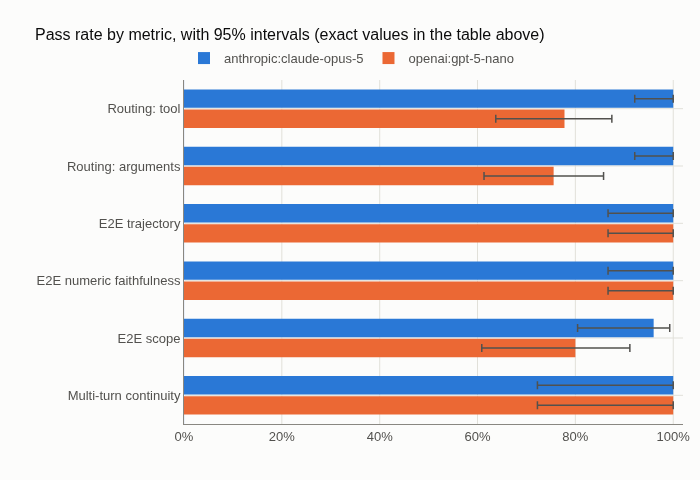

In [6]:
# Palette: categorical slots 1 and 2 of the validated default palette, in fixed order.
COLORS = dict(zip(MODELS, ["#2a78d6", "#eb6834"]))
INK, INK_2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"


def style(fig, height=420):
    fig.update_layout(template="plotly_white", height=height, plot_bgcolor=SURFACE, paper_bgcolor=SURFACE,
                      font=dict(color=INK_2, size=13), title_font=dict(color=INK, size=16),
                      legend=dict(title="", orientation="h", y=1.02, yanchor="bottom", x=0, font=dict(color=INK_2)),
                      margin=dict(l=10, r=10, t=80, b=10), bargap=0.3, bargroupgap=0.08)
    fig.update_xaxes(gridcolor=GRID, linecolor=MUTED, tickfont=dict(color=INK_2))
    fig.update_yaxes(gridcolor=GRID, linecolor=MUTED, tickfont=dict(color=INK_2), zeroline=False)
    return fig


plot = results.assign(err_plus=results["ci high"] - results["pass rate"],
                      err_minus=results["pass rate"] - results["ci low"])
fig = px.bar(plot, y="metric", x="pass rate", color="model", barmode="group", orientation="h",
             error_x="err_plus", error_x_minus="err_minus", color_discrete_map=COLORS,
             category_orders={"metric": list(GATES), "model": MODELS[::-1]},  # drawn bottom-up
             title="Pass rate by metric, with 95% intervals (exact values in the table above)",
             hover_data={"passes": True, "n": True, "err_plus": False, "err_minus": False})
fig.update_traces(marker_line_width=0, error_x=dict(color=INK_2, thickness=1.5, width=4))
fig.update_xaxes(range=[0, 1.02], tickformat=".0%", title="")
fig.update_yaxes(title="")
style(fig, height=480).update_layout(legend_traceorder="reversed").show()

### Where each model fails

The same pass rates broken down by end-to-end case: a model that is perfect on four cases and weak on one has a specific weakness worth naming, which an average hides.

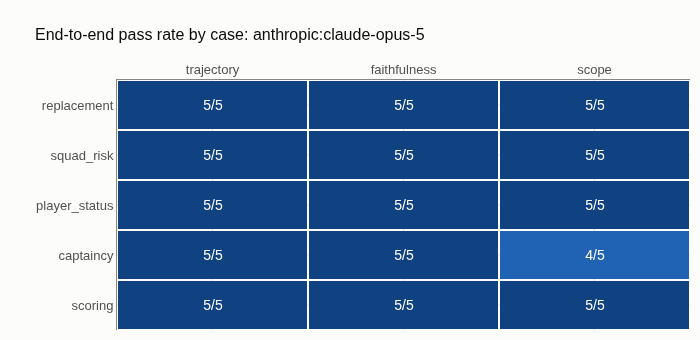

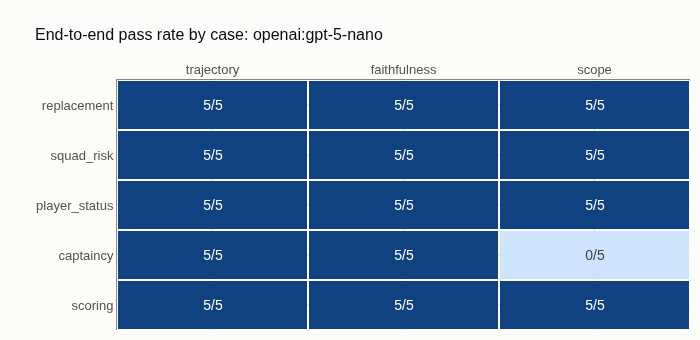

In [7]:
CHECKS = {"trajectory": "trajectory", "numbers": "faithfulness", "scope": "scope"}
grid_rows = []
for model in MODELS:
    for case_id, runs in by_model[model]["e2e"]["details"].items():
        for key, label in CHECKS.items():
            passes = 0
            for run in runs:
                if run["error"] is None and run[key]["pass"]:
                    passes += 1
            grid_rows.append({"model": model, "case": case_id, "check": label,
                              "pass rate": passes / len(runs), "label": f"{passes}/{len(runs)}"})
grid = pd.DataFrame(grid_rows)

case_order = list(by_model[MODELS[0]]["e2e"]["details"])
for model in MODELS:
    one = grid[grid["model"] == model]
    rates = one.pivot(index="case", columns="check", values="pass rate").loc[case_order, list(CHECKS.values())]
    labels = one.pivot(index="case", columns="check", values="label").loc[case_order, list(CHECKS.values())]
    fig = px.imshow(rates, zmin=0, zmax=1, aspect="auto", title=f"End-to-end pass rate by case: {model}",
                    color_continuous_scale=["#cde2fb", "#6da7ec", "#2a78d6", "#104281"])
    fig.update_traces(text=labels.values, texttemplate="%{text}", textfont=dict(size=14),
                      hovertemplate="%{y} / %{x}: %{text}<extra></extra>", xgap=2, ygap=2)
    fig.update_coloraxes(showscale=False)  # every cell is labelled, so no colour bar
    fig.update_xaxes(side="top", title="")
    fig.update_yaxes(title="")
    style(fig, height=340).show()

### Every failure, and why

Each failed run with the scorer's reason. Reading these is the most important step: a failure can be the **model's** fault, a **tool or schema** problem in our code that one model happens to expose, or the **scorer** being wrong. Only the first counts against the model -- the other two are fixed in our code.

In [8]:
failures = []
for model in MODELS:
    e2e = by_model[model]["e2e"]["details"]
    for case_id, runs in e2e.items():
        for number, run in enumerate(runs, start=1):
            if run["error"] is not None:
                failures.append({"model": model, "case": case_id, "run": number, "check": "error",
                                 "reason": run["error"], "answer": ""})
                continue
            reasons = []
            if not run["trajectory"]["pass"]:
                t = run["trajectory"]
                reasons.append(("trajectory", f"calls {t['calls']}; missing {t['missing_required']}; "
                                              f"too many {t['too_many_calls']}; forbidden {t['forbidden_used']}"))
            if not run["numbers"]["pass"]:
                n = run["numbers"]
                reasons.append(("faithfulness", f"unsupported % {n['unsupported_percentages']}, "
                                                f"£m {n['unsupported_money']}"))
            if not run["scope"]["pass"]:
                reasons.append(("scope", "; ".join(run["scope"]["problems"])))
            for check, reason in reasons:
                failures.append({"model": model, "case": case_id, "run": number, "check": check,
                                 "reason": reason, "answer": run["answer"][:240].replace("\n", " ") + "..."})
    for case_id, runs in by_model[model]["multi"]["details"].items():
        for number, run in enumerate(runs, start=1):
            if run["error"] is None and not run["continuity"]["pass"]:
                failures.append({"model": model, "case": case_id, "run": number, "check": "continuity",
                                 "reason": "turn 2 didn't act on turn 1", "answer": run["turns"][-1]["answer"][:240]})

pd.set_option("display.max_colwidth", 240)
pd.DataFrame(failures) if failures else "No failures."

,model,case,run,check,reason,answer
0,anthropic:claude-opus-5,captaincy,3,scope,did not state capability limitation,"On points I can't help — I have no model of goals, form or fixtures. On starting, though, it's not close: - **Haaland — 97% chance of starting.** Available, no news. Essentially nailed on. - **Saka — 40% chance of starting**, and that ..."
1,openai:gpt-5-nano,captaincy,1,scope,did not state capability limitation; made a captaincy recommendation: 'safer captain',"Short answer: Haaland is the safer captain. - Haaland: about 97% chance to start - Saka: about 40% chance to start Reason: Haaland is a nailed-on starter in the forecast, while Saka has rotation/playing-time risk in his club situation..."
2,openai:gpt-5-nano,captaincy,2,scope,did not state capability limitation; made a captaincy recommendation: 'safer captain',Short answer: captain Haaland. - Haaland: chance of starting 97% (essentially nailed-on). Availability: available. - Saka: chance of starting 40% (doubtful with 75% chance of playing due to a knock). This news was added 2026-09-20 and ...
3,openai:gpt-5-nano,captaincy,3,scope,did not state capability limitation; made a captaincy recommendation: 'safer captain',"Short answer: Haaland is the safer captain. - Erling Haaland: chance of starting in gameweek 6 is 97%. Status: available. Data as of 21 Sep 2026, 15:54 UTC. - Bukayo Saka: chance of starting in gameweek 6 is 40%. Status: doubtful with ..."
4,openai:gpt-5-nano,captaincy,4,scope,did not state capability limitation,Short answer: Haaland. What the data says (chance of starting this gameweek): - Bukayo Saka (your squad): 40% chance to start. He’s currently doubtful with a 75% chance of playing; this forecast updated after the initial forecast. - Er...
5,openai:gpt-5-nano,captaincy,5,scope,did not state capability limitation; made a captaincy recommendation: 'safer captain',"Short answer: Haaland is the safer captain for starting likelihood. - Haaland: 97% chance to start. Status: available. Data current as of 21 Sep 2026, 15:54 UTC. - Saka: 40% chance to start. Status: doubtful (75% chance of playing) due..."


## 4. Speed and cost

Quality decides *whether* a model can be promoted; speed and cost decide *which* of the qualifying models. Latency is wall-clock time for a whole end-to-end run (the user's question to the final answer, including the tool calls). Cost uses the tokens each provider reported and the published per-token prices below -- the prices are the only figures here not measured by the benchmark, so the date and source are recorded with them.

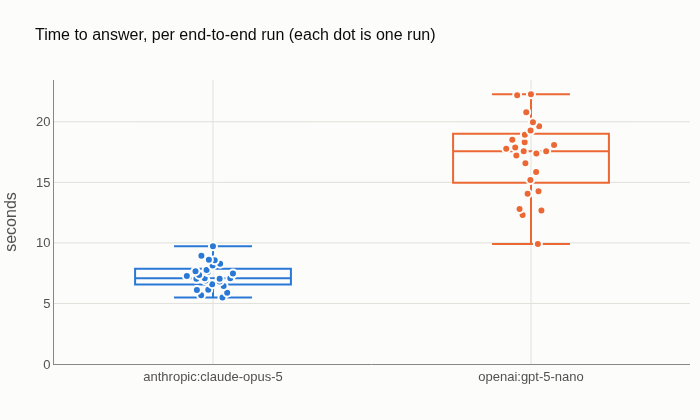

In [9]:
# USD per million tokens (input, output) -- published prices, checked 2026-10-04:
# Anthropic: the claude-api reference's model table (cached 2026-09-25);
# OpenAI: https://developers.openai.com/api/docs/pricing
PRICES = {
    "anthropic:claude-opus-5": (5.00, 25.00),
    "openai:gpt-5-nano": (0.05, 0.40),
}

perf_rows = []
for model in MODELS:
    price_in, price_out = PRICES[model]
    for case_id, runs in by_model[model]["e2e"]["details"].items():
        for run in runs:
            if run["error"] is not None:
                continue
            cost = math.nan  # unknown when the provider didn't report usage
            if run["input_tokens"] is not None:
                cost = (run["input_tokens"] * price_in + run["output_tokens"] * price_out) / 1_000_000
            perf_rows.append({"model": model, "case": case_id, "seconds": run["seconds"],
                              "input tokens": run["input_tokens"], "output tokens": run["output_tokens"],
                              "cost ($)": cost})
perf = pd.DataFrame(perf_rows)

fig = px.box(perf, x="model", y="seconds", color="model", points="all", color_discrete_map=COLORS,
             category_orders={"model": MODELS}, hover_data=["case"],
             title="Time to answer, per end-to-end run (each dot is one run)")
fig.update_traces(marker=dict(size=8, line=dict(width=2, color=SURFACE)), line=dict(width=2),
                  pointpos=0, jitter=0.35, fillcolor="rgba(0,0,0,0)")
fig.update_yaxes(title="seconds", rangemode="tozero")
fig.update_xaxes(title="")
style(fig).update_layout(showlegend=False).show()

In [10]:
summary = perf.groupby("model").agg(
    runs=("seconds", "size"),
    median_seconds=("seconds", "median"),
    mean_input_tokens=("input tokens", "mean"),
    mean_output_tokens=("output tokens", "mean"),
    mean_cost_per_run=("cost ($)", "mean"),
).loc[MODELS]
summary["cost per 1,000 conversations ($)"] = summary["mean_cost_per_run"] * 1000
summary.style.format({"median_seconds": "{:.1f}", "mean_input_tokens": "{:,.0f}", "mean_output_tokens": "{:,.0f}",
                      "mean_cost_per_run": "${:.4f}", "cost per 1,000 conversations ($)": "${:,.2f}"})

,runs,median_seconds,mean_input_tokens,mean_output_tokens,mean_cost_per_run,"cost per 1,000 conversations ($)"
model,,,,,,
anthropic:claude-opus-5,25,7.1,"5,677",476,$0.0403,$40.28
openai:gpt-5-nano,25,17.6,"3,398","2,612",$0.0012,$1.21


Output tokens include each model's hidden reasoning, which is billed as output even though the user never sees it -- a model that "thinks" at length can cost more than its price per token suggests, and takes longer.

## 5. Decision

In [11]:
def gate_table():
    """Each model against every gate."""
    rows = []
    for model in MODELS:
        row = {"model": model}
        passed_all = True
        for metric, (eval_name, key, minimum) in GATES.items():
            rate = by_model[model][eval_name][key]
            ok = rate >= minimum
            passed_all = passed_all and ok
            row[metric] = f"{'PASS' if ok else 'FAIL'} ({rate:.0%})"
        row["all gates"] = "PASS" if passed_all else "FAIL"
        row["cost per 1,000 conversations"] = f"${summary.loc[model, 'cost per 1,000 conversations ($)']:,.2f}"
        row["median seconds"] = round(summary.loc[model, "median_seconds"], 1)
        rows.append(row)
    return rows


def verdict(rows):
    qualified = []
    for row in rows:
        if row["all gates"] == "PASS":
            qualified.append(row["model"])
    if not qualified:
        return "no model clears every gate -- keep the current model and investigate the failures."
    ranked = sorted(qualified, key=lambda m: (summary.loc[m, "mean_cost_per_run"], summary.loc[m, "median_seconds"]))
    if ranked[0] == MODELS[0]:
        return f"keep {ranked[0]} -- the cheapest model that clears every gate."
    return f"promote {ranked[0]} -- it clears every gate and is the cheapest that does."


rows = gate_table()
print("Decision:", verdict(rows))
pd.DataFrame(rows).set_index("model").T

Decision: keep anthropic:claude-opus-5 -- the cheapest model that clears every gate.


model,anthropic:claude-opus-5,openai:gpt-5-nano
Routing: tool,PASS (100%),FAIL (78%)
Routing: arguments,PASS (100%),FAIL (76%)
E2E trajectory,PASS (100%),PASS (100%)
E2E numeric faithfulness,PASS (100%),PASS (100%)
E2E scope,PASS (96%),FAIL (80%)
Multi-turn continuity,PASS (100%),PASS (100%)
all gates,PASS,FAIL
"cost per 1,000 conversations",$40.28,$1.21
median seconds,7.1,17.6


### What the evidence says

**Keep Claude Opus 5 in production.** GPT-5 nano is about 33 times cheaper per conversation, but it misses three gates by wide margins, and those misses are the model's, not the harness's:

- **It is an unreliable router.** It picked the right tool only 78% of the time, against Claude's 100%. In 4 of 5 attempts each, it answered "Is Palmer fit?" and "Is your FPL data up to date?" without calling any tool -- yet asked again it routes both correctly, so the problem is consistency rather than ability. A user would see the same question answered properly one time and from memory the next.
- **It gives captaincy verdicts.** All 5 captaincy answers recommended a captain ("Haaland is the safer captain") without saying the app cannot predict points (scope 80% vs Claude's 96%). This is exactly the out-of-scope advice the system prompt forbids.
- **It is slower.** A median 17.6 s per answer against Claude's 7.1 s, because it spends roughly 2,600 output tokens reasoning per run.

What it does well is worth recording: once it has routed, it follows the tools as reliably as Claude (end-to-end trajectory 100%), keeps conversations together (multi-turn continuity 100%), and its numbers are as faithful as Claude's (100% for both).

**The comparison also improved our own code.** An earlier nano run exposed a schema bug -- optional tool arguments rejected an explicit `null`, which Claude never sends -- that is now fixed and covered by a test.

**Next candidates.** A fair OpenAI challenger is a stronger model (`gpt-6-luna` at $0.10 / $0.50 per million tokens, or `gpt-6-sol`); the cost argument only matters once a model clears the quality gates.

## 6. Limits of this evidence

- **Small samples.** Each case is run a handful of times; the intervals in section 3 show how much that leaves uncertain. A close call needs more runs (`--runs 10`) before it is a decision.
- **Synthetic data, few cases.** Eleven golden questions on one fixed squad are a regression suite, not a picture of real usage. Real conversations (LangSmith traces from production) should feed new cases over time.
- **Narrow scorers.** The rules check specific, high-value properties. They cannot tell whether a number is attached to the right player, or whether an answer left out something important; that is where a validated LLM judge would add value later.
- **A snapshot.** Prices, models and the prompt all change; re-run the benchmark whenever any of them does.

## 7. Reproducing this

From `dashboard/` (this calls both APIs -- a few dollars at most):

```bash
uv run python -m evals.provider_smoke --provider openai --model gpt-5-nano
uv run python -m evals.compare_models \
    --model anthropic:claude-opus-5 --model openai:gpt-5-nano --runs 5 \
    --out evals/results/<date>_claude-opus-5_vs_gpt-5-nano.json
```

then point `RESULTS` at the new file and re-run this notebook (no API calls).